# Preprocessing TCSPC Histograms

This notebook demonstrates the preprocessing tools introduced in Week 5 (of the initial Development Roadmap)
using a realistic IRF-convolved, Poisson-sampled TCSPC histogram.

The central idea is that **TCSPC preprocessing is analysis-dependent**.

Operations that are useful for visualization or machine-learning
representations are not necessarily appropriate before Poisson-likelihood
fitting.

In particular, we will distinguish between:

1. a statistical fitting workflow based on raw photon counts; and
2. a representation workflow based on cropping, rebinning, and normalization.

Throughout the notebook, the original measured histogram is retained as
`raw_counts` and is never modified in place.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tcspc_toolkit.config import CountNormalization
from tcspc_toolkit.convolution import convolve_decay_with_irf
from tcspc_toolkit.fitting import (
    fit_monoexponential_reconvolution,
    poisson_negative_log_likelihood,
)
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
)
from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.preprocessing import (
    align_to_irf,
    crop_time_window,
    detect_peak,
    estimate_background,
    normalize_counts,
    rebin_histogram,
    subtract_background,
    validate_histogram,
)
from tcspc_toolkit.simulation import sample_photon_counts

## 1. Generate a synthetic TCSPC measurement

We begin with a mono-exponential fluorescence decay

$$
I(t) = e^{-t/\tau},
$$

broaden it by a normalized instrument response function (IRF),

$$
\mu(t)
=
A\,[\mathrm{IRF} * I](t) + B,
$$

and finally draw the measured photon counts from a Poisson distribution,

$$
N_i \sim \mathrm{Poisson}(\mu_i).
$$

The resulting `raw_counts` array represents the measured TCSPC histogram.

In [2]:
n_bins = 1024
time = np.linspace(
    0.0,
    20.0,
    n_bins,
    dtype=np.float64,
)

true_lifetime_ns = 2.5
true_amplitude = 50_000.0
true_background = 5.0

irf_centre_ns = 2.0
irf_fwhm_ns = 0.25

In [3]:
irf = generate_gaussian_irf(
    time=time,
    centre=irf_centre_ns,
    fwhm=irf_fwhm_ns,
    amplitude=1.0,
)

irf = normalize_irf(
    time=time,
    irf=irf,
)

In [4]:
irf_area = np.trapezoid(
    irf,
    x=time,
)

print(f"Integrated IRF area: {irf_area:.6f}")

Integrated IRF area: 1.000000


In [5]:
decay = monoexponential_decay(
    time=time,
    amplitude=1.0,
    lifetime=true_lifetime_ns,
    background=0.0,
)

convolved_decay = convolve_decay_with_irf(
    time=time,
    decay=decay,
    irf=irf,
)

expected_counts = (
    true_amplitude * convolved_decay
    + true_background
)

In [6]:
rng = np.random.default_rng(42)

raw_counts = sample_photon_counts(
    expected_counts=expected_counts,
    rng=rng,
)

original_raw_counts = raw_counts.copy()

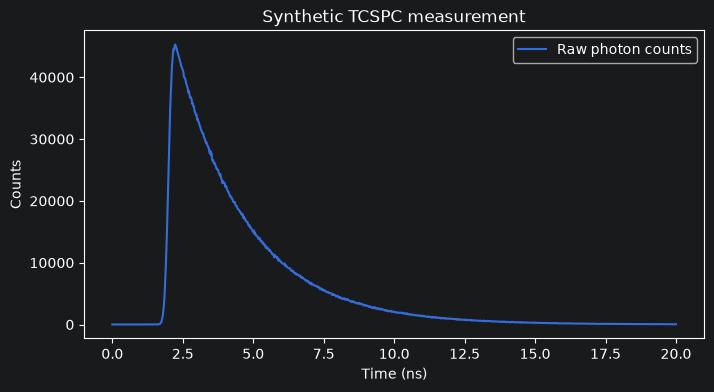

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_counts,
    label="Raw photon counts",
)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Counts")
ax.set_title("Synthetic TCSPC measurement")
ax.legend()

plt.show()

The sampled histogram is the quantity that represents the actual photon-count
measurement.

All subsequent processed arrays are derived representations. The original
`raw_counts` array will therefore be retained unchanged.

## 2. Validate the raw histogram

Before performing further analysis, we verify that the histogram satisfies
the structural assumptions of the toolkit:

- one-dimensional time and count arrays;
- equal array lengths;
- finite values;
- non-negative, integer-valued raw photon counts;
- strictly increasing and approximately uniform time bins.

In [8]:
validate_histogram(
    time=time,
    counts=raw_counts,
)

bin_width_ns = time[1] - time[0]
total_photons = np.sum(raw_counts)

print(f"Number of bins:     {raw_counts.size}")
print(f"Bin width:          {bin_width_ns:.6f} ns")
print(f"Total photon count: {total_photons}")

Number of bins:     1024
Bin width:          0.019550 ns
Total photon count: 6418068


## 3. Estimate the background

Because the synthetic IRF is centred near 2 ns, the beginning of the
measurement window contains effectively no fluorescence signal.

We use the first 50 bins as a known background-dominated interval and
estimate the stationary background from their mean count.

In [9]:
background_start_bin = 0
background_stop_bin = 50

estimated_background = estimate_background(
    raw_counts,
    start_bin=background_start_bin,
    stop_bin=background_stop_bin,
)

print(f"True background:      {true_background:.3f} counts/bin")
print(f"Estimated background: {estimated_background:.3f} counts/bin")

True background:      5.000 counts/bin
Estimated background: 4.840 counts/bin


The estimated background need not equal the true background exactly.

The true parameter \(B\) is the expected mean background count per bin,
whereas the observed background bins themselves are Poisson-distributed.
The estimate therefore fluctuates statistically around the true value.

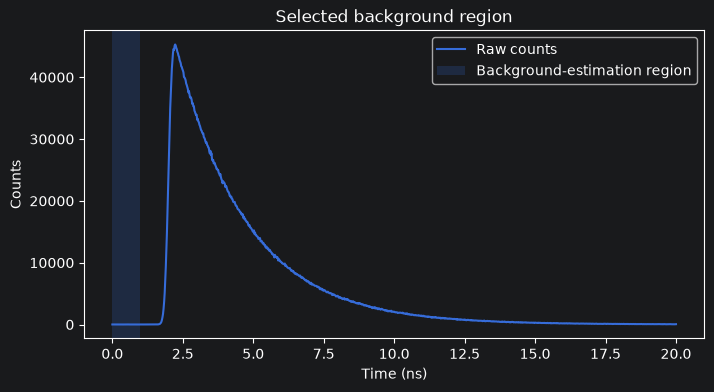

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_counts,
    label="Raw counts",
)

ax.axvspan(
    time[background_start_bin],
    time[background_stop_bin],
    alpha=0.2,
    label="Background-estimation region",
)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Counts")
ax.set_title("Selected background region")
ax.legend()

plt.show()

## 4. Demonstrate background subtraction

For visualization or certain downstream analyses, it can be useful to
subtract an estimated constant background.

However, this creates a processed signal rather than a raw photon-count
histogram.

In [11]:
background_subtracted_counts = subtract_background(
    raw_counts,
    background=estimated_background,
)

print(
    "Minimum background-subtracted value:",
    background_subtracted_counts.min(),
)

Minimum background-subtracted value: -3.84


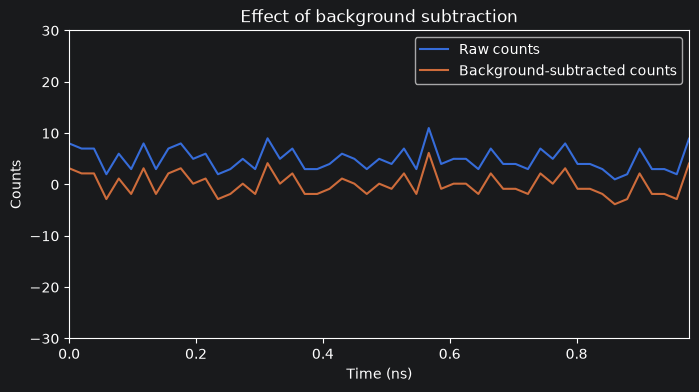

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_counts,
    label="Raw counts",
)

ax.plot(
    time,
    background_subtracted_counts,
    label="Background-subtracted counts",
)

ax.set_xlabel("Time (ns)")
ax.set_xlim([0, 50*bin_width_ns])
ax.set_ylabel("Counts")
ax.set_ylim([-30, 30])
ax.set_title("Effect of background subtraction")
ax.legend()

plt.show()

Negative values after background subtraction are not an error.

Individual background bins fluctuate above and below the estimated mean.
Subtracting that mean therefore naturally produces both positive and
negative residual values.

This processed signal is useful for visualization, but it is no longer a
raw Poisson count histogram.

For the current Poisson reconvolution fitter, the raw counts are retained.
The background is represented explicitly as a fitted parameter instead of
being subtracted from the observations beforehand.

## 5. Detect the peak of a measured IRF histogram

The normalized IRF used by the forward model is a continuous floating-point
kernel. In an experiment, however, an IRF may itself be measured as a
photon-count histogram.

To demonstrate `detect_peak()`, we generate a high-count Poisson realization
of the same IRF shape.

In [13]:
irf_expected_counts = (
    5_000.0
    * irf
    / np.max(irf)
)

irf_rng = np.random.default_rng(7)

measured_irf_counts = sample_photon_counts(
    expected_counts=irf_expected_counts,
    rng=irf_rng,
)

irf_peak_index = detect_peak(
    measured_irf_counts,
)

irf_peak_time = time[irf_peak_index]

print(f"IRF peak index: {irf_peak_index}")
print(f"IRF peak time:  {irf_peak_time:.6f} ns")

IRF peak index: 103
IRF peak time:  2.013685 ns


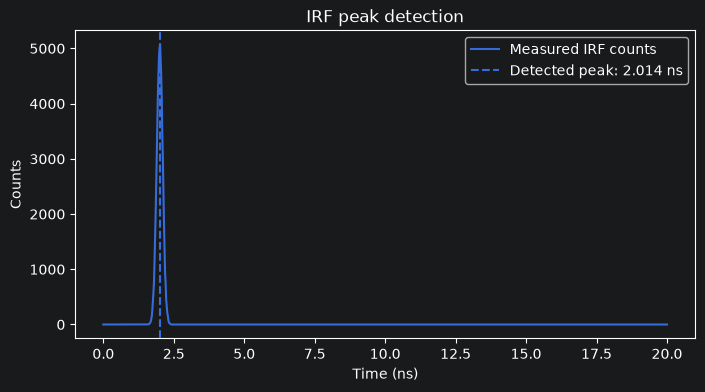

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    measured_irf_counts,
    label="Measured IRF counts",
)

ax.axvline(
    irf_peak_time,
    linestyle="--",
    label=f"Detected peak: {irf_peak_time:.3f} ns",
)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Counts")
ax.set_title("IRF peak detection")
ax.legend()

plt.show()

## 6. Align the time coordinate to the IRF

Temporal alignment does not change the measured photon counts.

Instead, it changes the coordinate system so that the maximum of the
continuous IRF occurs at

$$
t' = 0.
$$

This is a coordinate transformation rather than a transformation of the
measurement values.

In [15]:
aligned_time = align_to_irf(
    time=time,
    irf=irf,
)

continuous_irf_peak_index = int(
    np.argmax(irf)
)

print(
    "Aligned IRF peak time:",
    aligned_time[continuous_irf_peak_index],
)

Aligned IRF peak time: 0.0


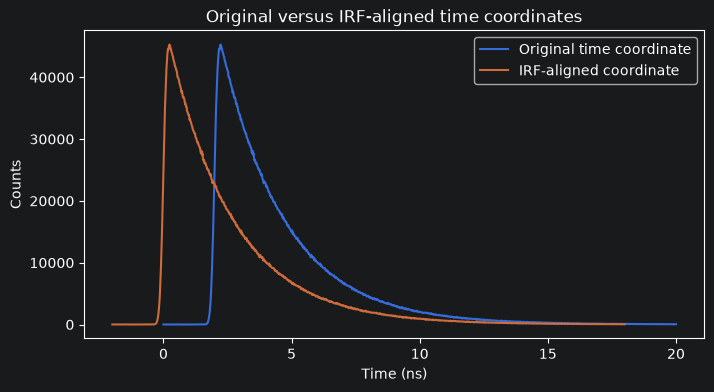

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_counts,
    label="Original time coordinate",
)

ax.plot(
    aligned_time,
    raw_counts,
    label="IRF-aligned coordinate",
)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Counts")
ax.set_title("Original versus IRF-aligned time coordinates")
ax.legend()

plt.show()

In [17]:
np.testing.assert_array_equal(
    raw_counts,
    original_raw_counts,
)

## 7. Crop a scientifically relevant time region

Once the IRF peak defines $t=0$, we can select a region relative to that
physical reference point.

Here we retain the interval

$$
0 \leq t < 10\ \mathrm{ns}.
$$

The toolkit uses half-open interval semantics:
the start boundary is included and the stop boundary is excluded.

In [18]:
crop_start_ns = 0.0
crop_stop_ns = 10.0

cropped_time, cropped_counts = crop_time_window(
    time=aligned_time,
    counts=raw_counts,
    start_time=crop_start_ns,
    stop_time=crop_stop_ns,
)

print(f"Original bins: {raw_counts.size}")
print(f"Cropped bins:  {cropped_counts.size}")

Original bins: 1024
Cropped bins:  512


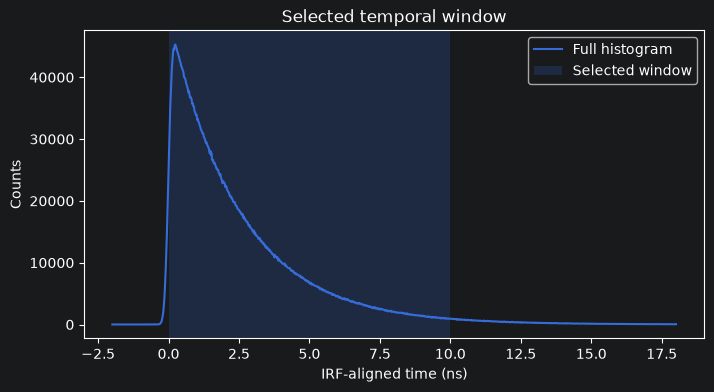

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    aligned_time,
    raw_counts,
    label="Full histogram",
)

ax.axvspan(
    crop_start_ns,
    crop_stop_ns,
    alpha=0.2,
    label="Selected window",
)

ax.set_xlabel("IRF-aligned time (ns)")
ax.set_ylabel("Counts")
ax.set_title("Selected temporal window")
ax.legend()

plt.show()

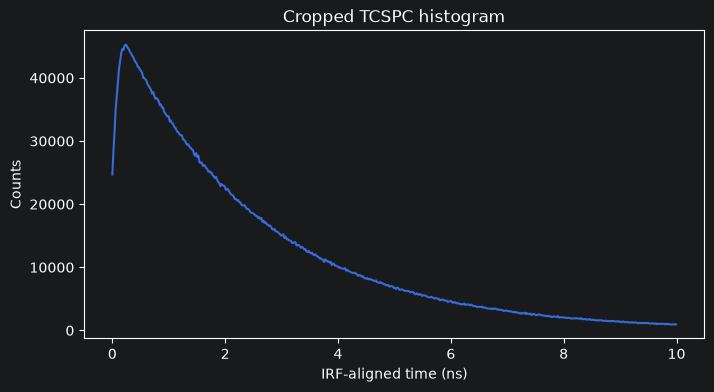

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    cropped_time,
    cropped_counts,
)

ax.set_xlabel("IRF-aligned time (ns)")
ax.set_ylabel("Counts")
ax.set_title("Cropped TCSPC histogram")

plt.show()

Cropping a histogram for visualization, machine learning, or selection of a
fitting region is not equivalent to truncating the signals before
reconvolution.

For reconvolution fitting, the forward model should generally be constructed
on the full time grid first. A fitting window can then be applied when
comparing observed and expected values.

Premature cropping of the IRF or decay can introduce convolution edge
effects.

## 8. Rebin the histogram

Rebinning combines neighboring temporal bins by summing their photon counts.

We compare factors

$$
1,\ 2,\ 4,\ 8.
$$

Increasing the factor reduces temporal resolution but increases the number
of photons represented by each bin.

In [21]:
rebin_factors = [1, 2, 4, 8]

rebinned_histograms = {}

for factor in rebin_factors:
    rebinned_time, rebinned_counts = rebin_histogram(
        time=aligned_time,
        counts=raw_counts,
        factor=factor,
    )

    rebinned_histograms[factor] = (
        rebinned_time,
        rebinned_counts,
    )

    assert (
        np.sum(rebinned_counts)
        == np.sum(raw_counts)
    )

    effective_bin_width = (
        bin_width_ns * factor
    )

    print(
        f"factor={factor}: "
        f"{rebinned_counts.size} bins, "
        f"bin width={effective_bin_width:.4f} ns, "
        f"photons={int(np.sum(rebinned_counts))}"
    )

factor=1: 1024 bins, bin width=0.0196 ns, photons=6418068
factor=2: 512 bins, bin width=0.0391 ns, photons=6418068
factor=4: 256 bins, bin width=0.0782 ns, photons=6418068
factor=8: 128 bins, bin width=0.1564 ns, photons=6418068


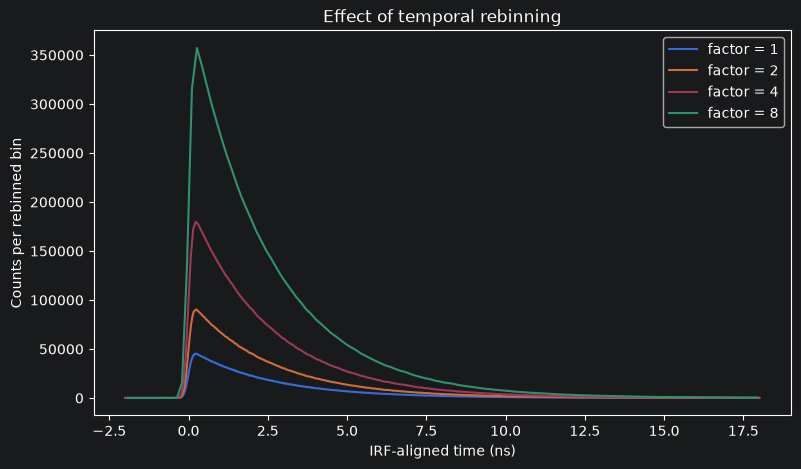

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

for factor in rebin_factors:
    rebinned_time, rebinned_counts = (
        rebinned_histograms[factor]
    )

    ax.plot(
        rebinned_time,
        rebinned_counts,
        label=f"factor = {factor}",
    )

ax.set_xlabel("IRF-aligned time (ns)")
ax.set_ylabel("Counts per rebinned bin")
ax.set_title("Effect of temporal rebinning")
ax.legend()

plt.show()

For Poisson-distributed counts,

$$
\sigma_N = \sqrt{N},
$$

so the relative statistical fluctuation is

$$
\frac{\sigma_N}{N}
=
\frac{1}{\sqrt{N}}.
$$

Combining neighboring bins therefore tends to increase the counts per bin
and reduce relative Poisson fluctuations.

The cost is lower temporal resolution.

Rebinning therefore represents a trade-off between:

- temporal resolution; and
- photons per bin / relative statistical noise.

## 9. Normalize counts

Normalization is useful when absolute brightness is not the quantity of
interest.

We compare two representations:

### Total normalization

$$
x_i = \frac{N_i}{\sum_j N_j}
$$

### Peak normalization

$$
x_i = \frac{N_i}{\max_j N_j}.
$$

These operations are useful for visualization, shape comparison, and
machine-learning representations, but they remove absolute photon-count
information.

In [23]:
total_normalized_counts = normalize_counts(
    cropped_counts,
    mode=CountNormalization.TOTAL,
)

peak_normalized_counts = normalize_counts(
    cropped_counts,
    mode=CountNormalization.PEAK,
)

print(
    "Total-normalized sum:",
    total_normalized_counts.sum(),
)

print(
    "Peak-normalized maximum:",
    peak_normalized_counts.max(),
)

Total-normalized sum: 1.0
Peak-normalized maximum: 1.0


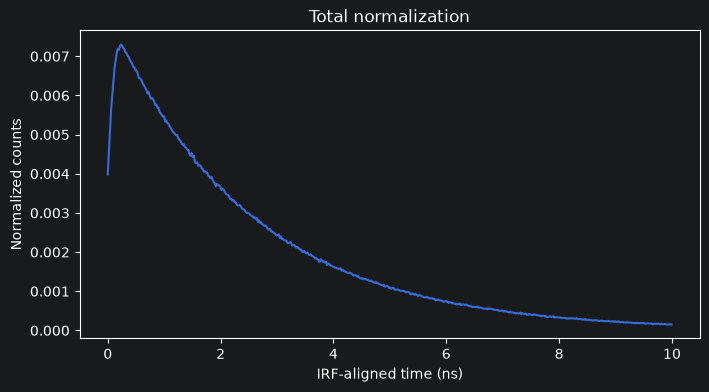

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    cropped_time,
    total_normalized_counts,
)

ax.set_xlabel("IRF-aligned time (ns)")
ax.set_ylabel("Normalized counts")
ax.set_title("Total normalization")

plt.show()

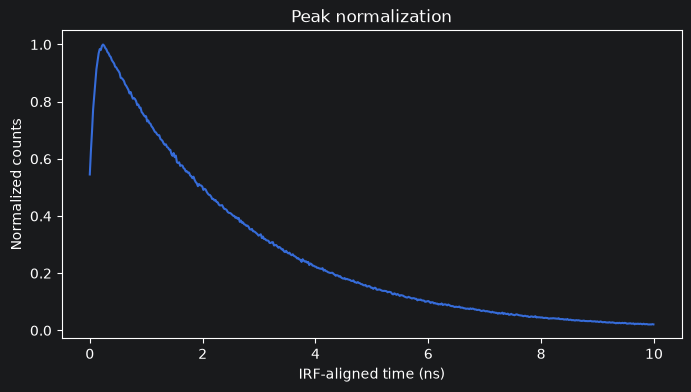

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    cropped_time,
    peak_normalized_counts,
)

ax.set_xlabel("IRF-aligned time (ns)")
ax.set_ylabel("Normalized counts")
ax.set_title("Peak normalization")

plt.show()

Normalization changes the statistical meaning of the data.

The raw measurement consists of photon counts $N_i$, for which the
Poisson model is

$$
N_i \sim \mathrm{Poisson}(\mu_i).
$$

After normalization, the values are no longer raw photon counts and the
absolute count scale has been removed.

For that reason, the present Poisson reconvolution fitter operates on the
original `raw_counts`, not on normalized data.

## 10. Compare two preprocessing strategies

The same TCSPC measurement can require different transformations depending
on the downstream scientific question.

There is therefore no universal preprocessing pipeline.

### Pipeline A — Poisson reconvolution fitting

For statistical fitting, the raw photon counts are retained:

```text
raw counts
    ↓
validation
    ↓
background estimate → initial background guess
    ↓
IRF information → temporal reference / shift information
    ↓
Poisson reconvolution fitting
```

In [26]:
background_guess = max(
    estimated_background,
    1e-6,
)

least_squares_fit = fit_monoexponential_reconvolution(
    time=time,
    counts=raw_counts,
    irf=irf,
    initial_guess=(
        0.9 * true_amplitude,
        2.0,
        background_guess,
        0.0,
    ),
    temporal_shift_bounds=(
        -0.5,
        0.5,
    ),
    objective="least_squares",
)

poisson_background_guess = max(
    least_squares_fit.background,
    1e-6,
)

poisson_fit = fit_monoexponential_reconvolution(
    time=time,
    counts=raw_counts,
    irf=irf,
    initial_guess=(
        least_squares_fit.amplitude,
        least_squares_fit.lifetime,
        poisson_background_guess,
        least_squares_fit.temporal_shift,
    ),
    temporal_shift_bounds=(
        -0.5,
        0.5,
    ),
    objective="poisson",
)

print(f"Least-squares success: {least_squares_fit.success}")
print(f"Poisson fit success:   {poisson_fit.success}")

print()
print(
    f"Lifetime:   true={true_lifetime_ns:.3f} ns, "
    f"fit={poisson_fit.lifetime:.3f} ns"
)
print(
    f"Background: true={true_background:.3f}, "
    f"fit={poisson_fit.background:.3f}"
)
print(
    f"Shift:      true=0.0000 ns, "
    f"fit={poisson_fit.temporal_shift:.4f} ns"
)

Least-squares success: True
Poisson fit success:   True

Lifetime:   true=2.500 ns, fit=2.500 ns
Background: true=5.000, fit=4.104
Shift:      true=0.0000 ns, fit=0.0002 ns


In [27]:
print(f"True amplitude:       {true_amplitude:.3f}")
print(f"Fitted amplitude:     {poisson_fit.amplitude:.3f}")
print()

print(f"True lifetime:        {true_lifetime_ns:.3f} ns")
print(f"Fitted lifetime:      {poisson_fit.lifetime:.3f} ns")
print()

print(f"True background:      {true_background:.3f}")
print(f"Fitted background:    {poisson_fit.background:.3f}")
print()

print(f"True temporal shift:  0.000 ns")
print(
    f"Fitted temporal shift: "
    f"{poisson_fit.temporal_shift:.6f} ns"
)

True amplitude:       50000.000
Fitted amplitude:     49997.518

True lifetime:        2.500 ns
Fitted lifetime:      2.500 ns

True background:      5.000
Fitted background:    4.104

True temporal shift:  0.000 ns
Fitted temporal shift: 0.000204 ns


In [28]:
fitted_nll = poisson_negative_log_likelihood(
    observed=raw_counts,
    expected=poisson_fit.fitted_curve,
)

true_model_nll = poisson_negative_log_likelihood(
    observed=raw_counts,
    expected=expected_counts,
)

print(f"NLL at fitted parameters: {fitted_nll:.3f}")
print(f"NLL at true parameters:   {true_model_nll:.3f}")

NLL at fitted parameters: -56412067.973
NLL at true parameters:   -56412075.644


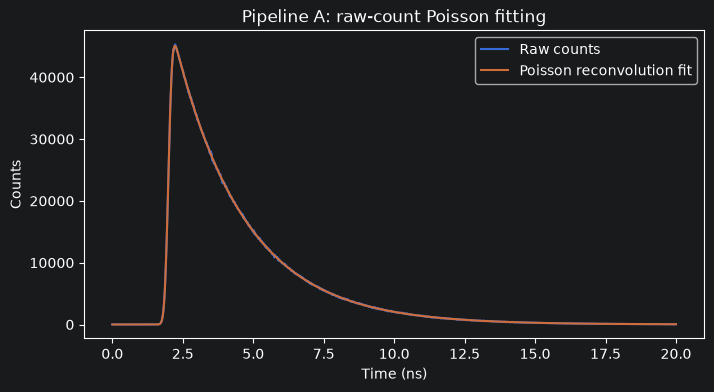

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_counts,
    label="Raw counts",
)

ax.plot(
    time,
    poisson_fit.fitted_curve,
    label="Poisson reconvolution fit",
)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Counts")
ax.set_title("Pipeline A: raw-count Poisson fitting")
ax.legend()

plt.show()

### Pipeline B — machine-learning representation

A machine-learning workflow may instead require a fixed-length,
scale-normalized representation:

```text
raw counts
    ↓
validation
    ↓
IRF alignment
    ↓
crop
    ↓
rebin
    ↓
normalize
    ↓
ML-ready vector

In [30]:
ml_time, ml_counts = rebin_histogram(
    time=cropped_time,
    counts=cropped_counts,
    factor=4,
)

ml_features = normalize_counts(
    ml_counts,
    mode=CountNormalization.TOTAL,
)

print(f"Cropped bins:      {cropped_counts.size}")
print(f"Rebinned bins:     {ml_counts.size}")
print(f"ML feature length: {ml_features.size}")
print(f"Feature sum:       {ml_features.sum():.6f}")

Cropped bins:      512
Rebinned bins:     128
ML feature length: 128
Feature sum:       1.000000


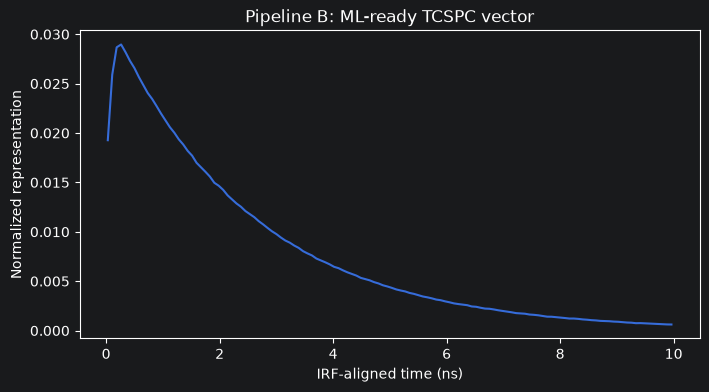

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    ml_time,
    ml_features,
)

ax.set_xlabel("IRF-aligned time (ns)")
ax.set_ylabel("Normalized representation")
ax.set_title("Pipeline B: ML-ready TCSPC vector")

plt.show()

In [32]:
np.testing.assert_array_equal(
    raw_counts,
    original_raw_counts,
)

print("Original raw histogram remains unchanged.")

Original raw histogram remains unchanged.
